# Week 5: DMRG

In all the exercises, consider a system of $n=20$ spin $1/2$ particles, unless otherwise specified. In all exercises, "solution" means the best solution provided by DMRG.

In [1]:
include("./dmrg_helper_functions.jl")

Main.DMRGHelperFunctions

In [2]:
using Pkg
Pkg.activate("..")
using ITensors
using ITensorMPS
using LinearAlgebra
using Test
using Printf
using .DMRGHelperFunctions #this carries the functions defined in the included module into the current namespace, so that we can call them without the module prefix.

  Activating project at `c:\Users\mariu\GithubCloneTN\TN_Notebooks`


In [3]:
nn = 20
system = siteinds("S=1/2", nn);

## Exercise 1

Determine the minimal bond dimension providing an accurate solution of the Heisenberg Hamiltonian for $J=1$ and $g=30$ ( see `dmrg_single_site.ipynb`). How do you expect the bond dimension to scale with the number of sites? Why?

In [4]:
jj = 1.0
g = 30.0
opsum = OpSum()
for j in 1:nn-1
    opsum += -jj , "S-", j, "S+", j+1
    opsum += -jj, "S+", j, "S-", j+1
end
for j in 1:nn-1
    opsum += -g * jj,"Z", j, "Z", j+1
end
ham = MPO(opsum, system);

In [5]:
bond_dim = 32
psi0 = random_mps(ComplexF64, system, linkdims=bond_dim)
orthogonalize!(psi0, 1)
H = ham
N = length(psi0)
psi = copy(psi0)
#R = build_right_blocks(psi, H)
#L = Vector{ITensor}(undef, N)  # L[k] viene riempito on-the-fly
maxdim::Int=100
cutoff::Float64=1e-14
tol_davidson::Float64=1e-14
maxiter_davidson::Int=50
E = 0.0

energies = Float64[]
bestState = copy(psi0)
norms = Float64[]
min_energy::Float64 = Inf
pos_min_energy::Int = 0

fileout = open("dmrg_single_site_output.txt", "w")

nsweeps = 30

for sweep in 1:nsweeps

    println("Sweep: $sweep")
    # ── Sweep L -> R ──────────────────────────────────────────
    # ── Reconstruct right blocks starting from the right. Right blocks are not changed during a L -> R  sweep ──
    R = build_right_blocks(psi, H)
    
    # Left blocks are built on the finally
    L = Vector{ITensor}(undef, N)

    #Inline definition of the apply_H function for the Davidson algorithm
    #Scope: visible within the loop, can access L and R which are updated at each iteration
    
    #Left-sweep: k=1,...,N-1
    for k in 1:N-1
        apply_H = v -> begin
            Hv = v * H[k]
            if k > 1; Hv = Hv * L[k-1]; end
            Hv = Hv * R[k+1]
            noprime(Hv)
        end

        println(fileout,"L->R: Updating site $k sweep $sweep")
        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #psi[k] updated. The overall dimension chi_{k-1} x d_k x chi_{k} of the output is the same as the input.
        #Now we need to shift the orthogonality center to k+1, which means:
        #psi[k] -> left-orthogonal 
        #psi[k+1] -> OC

        #Determine the left indices to perform the SVD. For k=1 we have only the physical index, while for k>1 we have both the left link and the physical index.
        #Note: linkind(psi, k-1) is the left link index of psi[k], while siteind(psi, k) is the physical index of psi[k]. The SVD will be performed by grouping these indices together as "left" indices, and the remaining right link index (if k>1) will be the "right" index.
        linds = (k == 1) ? [siteind(psi, k)] :
                           [linkind(psi, k-1), siteind(psi, k)]

        #Perform the SVD
        #We set cutoff=0 to keep all the singular values The lefttags argument is used to tag the left link index of U with "Link,l=k", which will be useful for the next iteration when we need to identify this index.
        #Note that we assign tags to the left and right link indices of U,S, and V, which will be useful for the next iteration when we need to identify these indices after the shift of the OC is completed. 
        U, S, V = svd(psi[k], linds; cutoff=0,
                      lefttags="Link,l=$k",righttags="Link,l=$k")
        #psi[k] is now left-orthogonal, while psi[k+1] is updated to be the new OC tensor by contracting S and V with the old psi[k+1]
        psi[k]   = U
        psi[k+1] = S * dag(V) * psi[k+1]

        #We update(actually assign) the left block L[k] on-the-fly using the updated psi[k]. This is possible because L[k] depends only on psi[1],...,psi[k], which are all updated at this point. In this way we avoid to reconstruct the left blocks from scratch at each iteration, which would be more expensive.
        L[k] = (k == 1) ?
            psi[k] * H[k] * dag(prime(psi[k])) :
            L[k-1] * psi[k] * H[k] * dag(prime(psi[k]))
    end #L->R sweep
    
    println(fileout,"After L->R sweep, sweep = $sweep, E = $E")

    #After the end of L->R we have all the L blocks L[1],...,L[N-1] updated.  The site N is the OC, and it will be updated during the R->L sweep.
#     # ── Sweep R -> L ──────────────────────────────────────────

# The blocks R[k],k=N,N-1,2 are built on the fly after the update of psi[k] during the R->L sweep, starting from the rightmost site. This is possible because R[k] depends only on psi[k],...,psi[N].

R = Vector{ITensor}(undef, N)


    for k in N:-1:2

        println(fileout,"R->L: Updating site $k sweep $sweep")
        apply_H = v -> begin
            Hv = v * H[k]
            if k < N; Hv = Hv * R[k+1]; end
            Hv = Hv * L[k-1]
            noprime(Hv)
        end


        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #Treat the site index and the right link index of psi[k] as "row" indices for the SVD.
        rinds = (k == N) ? [siteind(psi, k)] :                        
        [siteind(psi, k), linkind(psi, k)]
        
        #Perform the SVD to shift the OC to the left. Note that for k=N we have only the physical index, while for k<N we have both the physical index and the right link index.

        U, S, V = svd(psi[k], rinds;  cutoff=0,lefttags="Link,l=$(k-1)",righttags="Link,l=$(k-1)")

        psi[k]   = U
        psi[k-1] = psi[k-1] * S * dag(V)


        # build R[k] with updated psi[k]
        R[k] = (k==N) ? psi[k] * H[k] * dag(prime(psi[k])) : psi[k] * H[k] * dag(prime(psi[k])) * R[k+1]
               

    end #End of R->L sweep
    flush(fileout)
    en = real(inner(psi', ham, psi))
    @printf("sweep = %d | E = %.12f | maxdim = %d\n",
             sweep, en, maxlinkdim(psi))
    
    #store intermediate energies and states
    push!(energies, en)
    push!(norms, norm(psi))
    if en < min_energy
        min_energy = en
        pos_min_energy = sweep
        bestState = copy(psi)
        end
end

close(fileout)
         

Sweep: 1
sweep = 1 | E = -569.999945487166 | maxdim = 32
Sweep: 2
sweep = 2 | E = -568.204629379709 | maxdim = 32
Sweep: 3
sweep = 3 | E = -569.999998409583 | maxdim = 32
Sweep: 4
sweep = 4 | E = -569.999796491983 | maxdim = 32
Sweep: 5
sweep = 5 | E = -569.997530049563 | maxdim = 32
Sweep: 6
sweep = 6 | E = -569.296299564567 | maxdim = 32
Sweep: 7
sweep = 7 | E = -568.924599619549 | maxdim = 32
Sweep: 8
sweep = 8 | E = -568.656177703640 | maxdim = 32
Sweep: 9
sweep = 9 | E = -564.688485029322 | maxdim = 32
Sweep: 10
sweep = 10 | E = -567.019261295154 | maxdim = 32
Sweep: 11
sweep = 11 | E = -569.949989778185 | maxdim = 32
Sweep: 12
sweep = 12 | E = -568.127879000919 | maxdim = 32
Sweep: 13
sweep = 13 | E = -568.522101667394 | maxdim = 32
Sweep: 14
sweep = 14 | E = -569.624985603260 | maxdim = 32
Sweep: 15
sweep = 15 | E = -568.162662578584 | maxdim = 32
Sweep: 16
sweep = 16 | E = -566.181951336085 | maxdim = 32
Sweep: 17
sweep = 17 | E = -569.999999991136 | maxdim = 32
Sweep: 18
sweep

In [6]:
using Plots

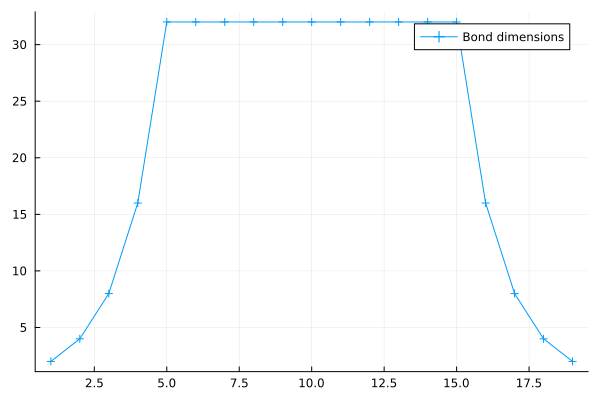

In [7]:
bondDims=[linkdim(bestState, k) for k in 1:N-1]
plot(bondDims, marker=:+, label="Bond dimensions")

## Exercise 2

Explore the anti-ferromagnetic (Néel) phase ($J=1$, $g \ll -1$, e.g. $g=-30$) of the Heisenberg Hamiltonian discussed in the notebook `dmrg_single_site.ipynb`. Determine the ground state, inspect the average number of spin-up,  and compute the two-point correlators $\langle \sigma_z^i, \sigma_z^j \rangle$ for the _best_ solution determined by DMRG. Use the DMRG version of your preference. As done in Exercise 1, determine the minimal bond dimension providing an accurate approximation of the ground state and motivate the result.

## Exercise 3

Determine, by means of DMRG, the ground state of the $XY$ model ($J=1, g=0$). Compare the so obtained ground state energy with the analytic value. Determine, as done in the previous exercises, the minimal bond dimension providing accurate results for $n=20$ and then do the same for $n=5,10,15, 25, 30$. Does the minimal bond dimension scale with the number of sites?

## Exercise 4

So far we have always used system of spin $1/2$ particles. ITensor provides other `SiteTypes`. Among them there is the `Boson` type (see the documentation [_here_](https://docs.itensor.org/ITensorMPS/stable/IncludedSiteTypes.html)). Mind that, for obvious reasons, bosons are represented in the Fock space and truncated. 

Determine the ground state of the Hamiltonian:

$$ H = \omega \sum_{i=1}^n  a_i^\dagger a_i + \kappa \sum_{i=1}^{n-1} k_i (a_{i+1}^\dagger a_i + \text{h.c.}) $$

for $n=20$. The Hamiltonian represents a homogeneous chain of bosons with nearest-neighbor interaction.